## Test maier saupe distribution

### Distribution normalisée avec centre libre

In [1]:
import numpy as np
from scipy.integrate import quad

# --- Normalisation ---
def Z_m(m, x0=0):
    """Z(m,x0) = ∫_0^π exp(m cos²(θ-x0)) sinθ dθ"""
    integrand = lambda theta: np.exp(m * np.cos(theta - np.radians(x0))**2) * np.sin(theta)
    Z, _ = quad(integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)
    return Z

def maier_saupe(theta, m, x0=0):
    """Distribution normalisée de Maier-Saupe avec centre libre x0 (en degrés)."""
    theta = np.radians(theta)  # angles en radians
    return np.exp(m * np.cos(theta - np.radians(x0))**2) / Z_m(m, x0)


### Calcul de S

In [2]:
def S_from_m(m, x0=0):
    """Paramètre d'ordre S pour Maier-Saupe avec centre libre x0."""
    num_integrand = lambda theta: (0.5 * (3*np.cos(theta - np.radians(x0))**2 - 1)) \
                                  * np.exp(m*np.cos(theta - np.radians(x0))**2) * np.sin(theta)
    den_integrand = lambda theta: np.exp(m*np.cos(theta - np.radians(x0))**2) * np.sin(theta)

    num, _ = quad(num_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)
    den, _ = quad(den_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)

    return num / den


### Modèle pour fit de profils expérimentaux

In [3]:
def ms_model(theta_deg, I0, m, x0, a, b):
    """
    Modèle pour l'ajustement expérimental.
    theta_deg : angles en degrés
    I0 : facteur d'échelle
    m : paramètre Maier-Saupe
    x0 : centre de la distribution (en degrés)
    a, b : fond linéaire
    """
    return I0 * maier_saupe(theta_deg, m, x0) + a*theta_deg + b


### Test sur profil expérimental (SAXS)

Fit: I0=621.7, m=110.29, x0=90.2°, S=0.993


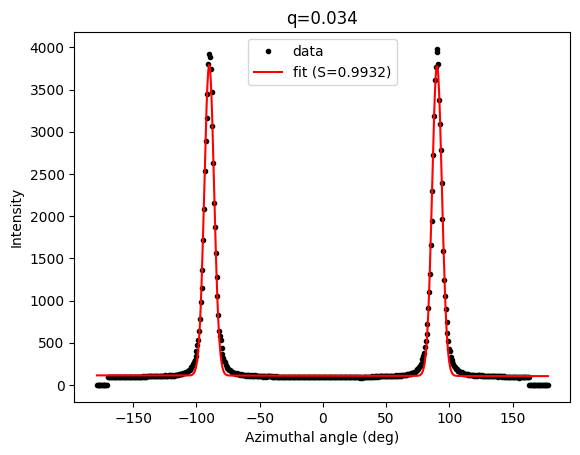

Fit: I0=28.1, m=144.97, x0=90.2°, S=0.995


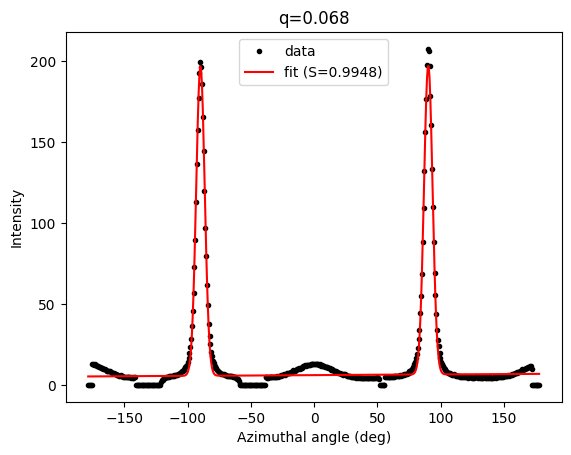

Fit: I0=1690.4, m=16.06, x0=91.5°, S=0.953


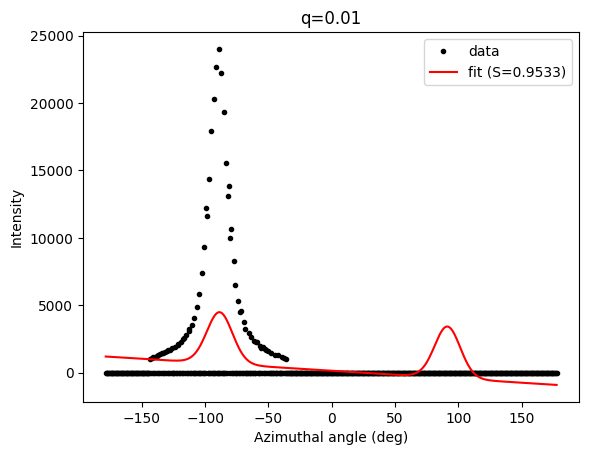

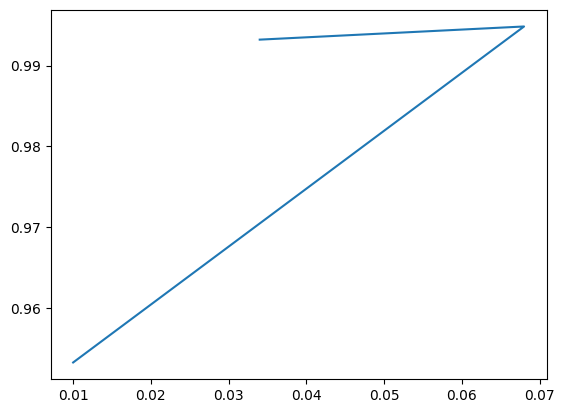

In [4]:
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

path = '/home-local/ratel-ra/Bureau/ESRF_DATA/Co12tol/Azimuthal_Profiles'
q_array=[0.034,0.068,0.01]
S_fit=np.zeros(len(q_array),dtype = float)
for j,q in enumerate(q_array):    
    csv_file = path+f'/file_00532_Co12_tol1_1000mT_q={q}_azim_profile_pyFAI.csv'
    df=pd.read_csv(csv_file, header = None)
    theta_exp,I_exp =df[0].values, df[1].values
    

        # --- Fit ---
    p0 = [500, 2.0, 80.0, 0.0, 10.0]  # guesses
    bounds = ([0, 0, 0, -np.inf, -np.inf], [np.inf, np.inf, 180, np.inf, np.inf])
    popt, pcov = curve_fit(ms_model, theta_exp, I_exp, p0=p0, bounds=bounds)

    I0_fit, m_fit, x0_fit, a_fit, b_fit = popt
    S_fit[j] = S_from_m(m_fit, x0_fit)

    print(f"Fit: I0={I0_fit:.1f}, m={m_fit:.2f}, x0={x0_fit:.1f}°, S={S_fit[j]:.3f}")

    # --- Plot ---
    plt.figure()
    plt.plot(theta_exp, I_exp, 'k.', label="data")
    plt.plot(theta_exp, ms_model(theta_exp, *popt), 'r-', label=f"fit (S={S_fit[j]:.4f})")
    plt.title(f'q={q}')
    plt.xlabel("Azimuthal angle (deg)")
    plt.ylabel("Intensity")
    plt.legend()
    plt.show()

plt.figure()
plt.plot(q_array, S_fit)

### Profil miroir

Le profil pour q=0.1 ne présente qu'un seul pic (ce sera le cas aussi des données WAXS). Il faut donc une fonction qui puisse calculer le profil miroir

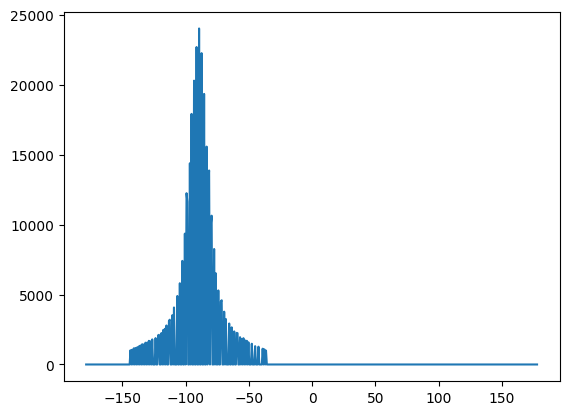

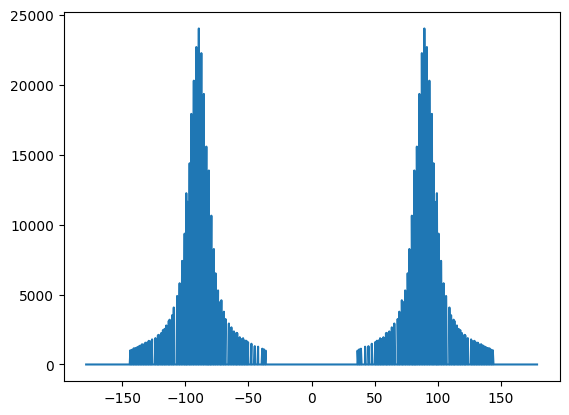

In [5]:
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

def mirror_profile(theta_exp, I_exp, center=180):
    """
    Génère un profil azimutal symétrique sans interpolation,
    angles dans [-180°, 180°].
    """
    theta_exp = np.array(theta_exp)
    I_exp = np.array(I_exp)
    
    # --- Détecter le pic principal ---
    peaks, _ = find_peaks(I_exp, height=0)
    if len(peaks) == 0:
        raise ValueError("Aucun pic détecté.")
    
    main_peak = peaks[np.argmax(I_exp[peaks])]
    x0 = theta_exp[main_peak]
    
    # --- Calculer les angles miroir ---
    theta_mirror_array = (2*center - theta_exp) % 360
    I_mirror_array = I_exp.copy()  # intensité identique
    
    # --- Fusionner ---
    theta_aug = np.concatenate([theta_exp, theta_mirror_array])
    I_aug = np.concatenate([I_exp, I_mirror_array])
    
    # --- Mapper dans [-180, 180] et trier ---
    theta_aug = ((theta_aug + 180) % 360) - 180
    sort_idx = np.argsort(theta_aug)
    
    return theta_aug[sort_idx], I_aug[sort_idx]

theta_aug, I_aug=mirror_profile(theta_exp,I_exp)

plt.figure()
plt.plot(theta_exp,I_exp,label='exp')
plt.figure()
plt.plot(theta_aug,I_aug,label='mirror')


### Test avec application du miroir
Le miroir n'est appliqué que si 1 pic est détecté dans le profil azimuthal


q=0.010 → 1 pic(s) détecté(s).
Fit: I0=0.0, m=13.57, x0=90.0°, S=0.872


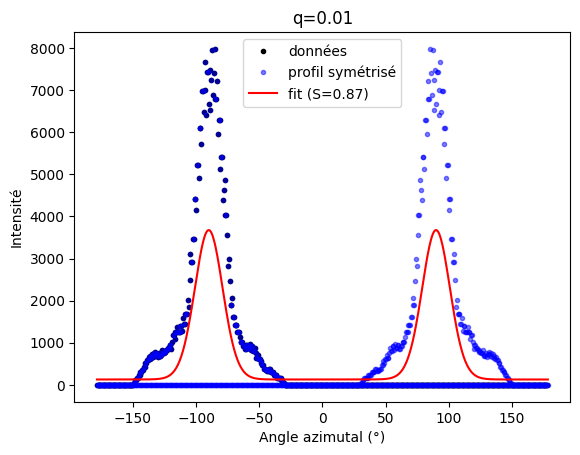

q=0.034 → 2 pic(s) détecté(s).
Fit: I0=0.0, m=39.84, x0=90.2°, S=0.952


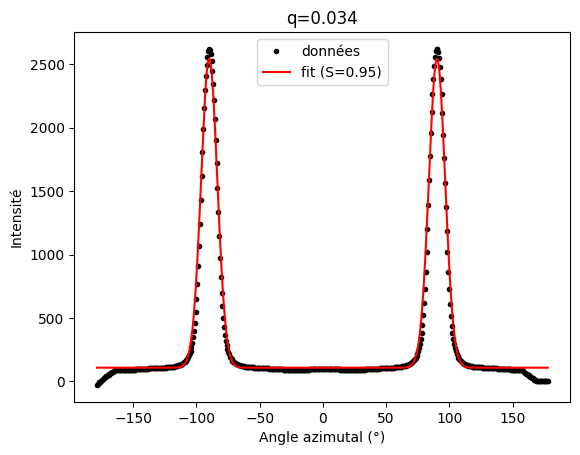

q=0.068 → 2 pic(s) détecté(s).
Fit: I0=0.0, m=16.42, x0=90.1°, S=0.891


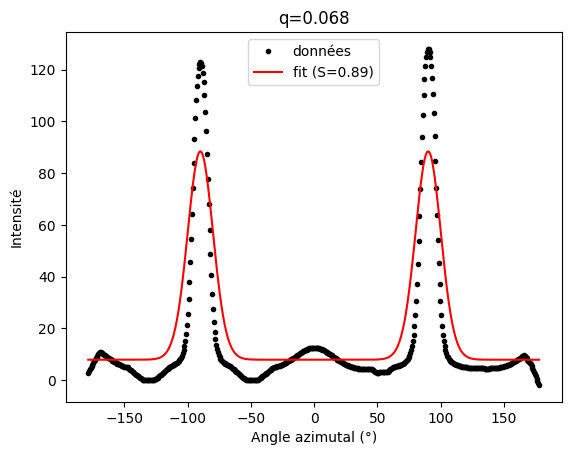

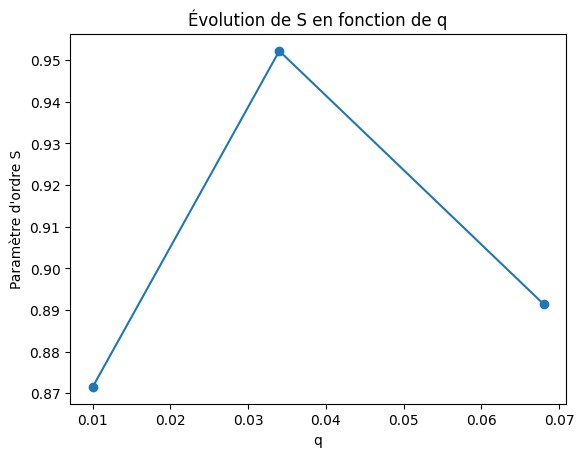

In [6]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
import matplotlib.pyplot as plt

# === Modèle symétrique ===
def ms_model(theta, I0, m, x0, a, b):
    # Une seule gaussienne de Von Mises (cos^2) centrée en x0
    # Ce modèle est intrinsèquement symétrique
    return I0 * np.exp(m * np.cos(np.radians(theta - x0))**2) + a + b

# === Miroir sur les données ===
def mirror_profile_simple(theta_exp, I_exp, center=180):
    """
    Si un seul pic est détecté : génère un profil miroir
    angles sortis dans [-180°, 180°].
    """
    theta_exp = np.array(theta_exp)
    I_exp = np.array(I_exp)
    
    # Symétrie par rapport à "center"
    theta_mirror_array = (2*center - theta_exp) % 360
    I_mirror_array = I_exp.copy()
    
    # Fusion
    theta_aug = np.concatenate([theta_exp, theta_mirror_array])
    I_aug = np.concatenate([I_exp, I_mirror_array])
    
    # Replie dans [-180,180]
    theta_aug = ((theta_aug + 180) % 360) - 180
    sort_idx = np.argsort(theta_aug)
    
    return theta_aug[sort_idx], I_aug[sort_idx]

# === Exemple de calcul de S ===
def S_from_m(m, x0):
    # placeholder : adapter selon ta vraie formule
    return (m / (m + 2)) if m > 0 else 0

# === Code principal ===
path = '/home-local/ratel-ra/Bureau/ESRF_DATA/Co12tol/Azimuthal_Profiles'
q_array = [0.01,0.034, 0.068]
S_fit = np.zeros(len(q_array), dtype=float)

for j, q in enumerate(q_array):
    csv_file = path + f'/file_00532_Co12_tol1_1000mT_q={q}_azim_profile_pyFAI.csv'
    df = pd.read_csv(csv_file, header=None)
    theta_exp, I_exp = df[0].values, df[1].values
    I_exp = savgol_filter(I_exp,19,1)
    # --- Détection des pics ---
    threshold = 0.9 * I_exp.max()  # 50% du max
    peaks, props = find_peaks(I_exp, prominence=0.9*I_exp.max(),height=threshold)
    n_peaks = len(peaks)
    print(f"q={q:.3f} → {n_peaks} pic(s) détecté(s).")

    # Si 1 seul pic → symétrisation des données
    if n_peaks == 1:
        theta_fit, I_fit = mirror_profile_simple(theta_exp, I_exp, center=180)
    else:
        theta_fit, I_fit = theta_exp, I_exp
    
    # --- Fit ---
    p0 = [500, 10.0, 90.0, 0.0, 10.0]  # I0, m, x0, a, b
    bounds = ([0, 0, 0, -np.inf, -np.inf], [np.inf, np.inf, 180, np.inf, np.inf])
    popt, pcov = curve_fit(ms_model, theta_fit, I_fit, p0=p0, bounds=bounds,method='dogbox')

    I0_fit, m_fit, x0_fit, a_fit, b_fit = popt
    S_fit[j] = S_from_m(m_fit, x0_fit)

    print(f"Fit: I0={I0_fit:.1f}, m={m_fit:.2f}, x0={x0_fit:.1f}°, S={S_fit[j]:.3f}")

    # --- Plot ---
    plt.figure()
    plt.plot(theta_exp, I_exp, 'k.', label="données")
    if n_peaks == 1:
        plt.plot(theta_fit, I_fit, 'b.', alpha=0.5, label="profil symétrisé")
    plt.plot(theta_fit, ms_model(theta_fit, *popt), 'r-', label=f"fit (S={S_fit[j]:.2f})")
    plt.title(f'q={q}')
    plt.xlabel("Angle azimutal (°)")
    plt.ylabel("Intensité")
    plt.legend()
    plt.show()

# --- Résumé ---
plt.figure()
plt.plot(q_array, S_fit, 'o-')
plt.xlabel("q")
plt.ylabel("Paramètre d'ordre S")
plt.title("Évolution de S en fonction de q")
plt.show()


### Mêle code mais fonctionnalisé

In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks,savgol_filter

# === Modèle symétrique ===
def ms_model(theta, I0, m, x0, a, b):
    return I0 * np.exp(m * np.cos(np.radians(theta - x0))**2) + a + b

# === Génération du profil miroir ===
def mirror_profile_simple(theta_exp, I_exp, center=180):
    theta_exp = np.array(theta_exp)
    I_exp = np.array(I_exp)
    theta_mirror_array = (2*center - theta_exp) % 360
    I_mirror_array = I_exp.copy()
    theta_aug = np.concatenate([theta_exp, theta_mirror_array])
    I_aug = np.concatenate([I_exp, I_mirror_array])
    theta_aug = ((theta_aug + 180) % 360) - 180
    sort_idx = np.argsort(theta_aug)
    return theta_aug[sort_idx], I_aug[sort_idx]

# === Exemple de calcul de S ===
def S_from_m(m, x0):
    return (m / (m + 2)) if m > 0 else 0

# === Fonction de fit ===
def azim_profile_fit_MS(theta_exp, I_exp, peak_threshold=0.9,prominence_threshold = 0.9):
    """
    Fit d'un profil azimutal avec détection automatique des pics.
    Si un seul pic est trouvé, symétrisation avant le fit.
    
    Paramètres
    ----------
    theta_exp : array_like
        Angles expérimentaux en degrés
    I_exp : array_like
        Intensités expérimentales
    peak_threshold : float
        Seuil relatif pour la détection de pics (par rapport au max), ex: 0.5 = 50%
    
    Retour
    ------
    popt : array
        Paramètres optimisés [I0, m, x0, a, b]
    S : float
        Paramètre d’ordre extrait
    theta_fit, I_fit : arrays
        Données utilisées pour le fit (symétrisées si nécessaire)
    """
    # Filtre Savitzky-Golay
    I_exp=savgol_filter(I_exp,9,1)
    # --- Détection de pics principaux ---
    threshold = peak_threshold * I_exp.max()
    peaks, props = find_peaks(I_exp, height=threshold,prominence=prominence_threshold*I_exp.max())
    n_peaks = len(peaks)

    if n_peaks == 0:
        raise RuntimeError("Aucun pic détecté au-dessus du seuil.")
    
    # --- Si un seul pic → symétrisation ---
    if n_peaks == 1:
        theta_fit, I_fit = mirror_profile_simple(theta_exp, I_exp, center=180)
    else:
        theta_fit, I_fit = theta_exp, I_exp

    # --- Fit ---
    p0 = [I_fit.max(), 2.0, float(theta_fit[np.argmax(I_fit)]), 0.0, np.median(I_fit)]
    bounds = ([0, 0, -180, -np.inf, -np.inf],
              [np.inf, np.inf, 180, np.inf, np.inf])
    popt, pcov = curve_fit(ms_model, theta_fit, I_fit, p0=p0, bounds=bounds)
    
    I0_fit, m_fit, x0_fit, a_fit, b_fit = popt
    S = S_from_m(m_fit, x0_fit)

    return popt, S, theta_fit, I_fit
